# NHANES Pulse Consumption — Replication Analysis

Replicates key findings from Drewnowski et al. (2025) *Frontiers in Nutrition*:
- Consumer prevalence by demographics
- Mean consumption amounts (oz equivalents/day)
- Table 1: Characteristics of pulse consumers vs non-consumers
- Consumption by pulse type

**Sensitivity analysis**: Compares broad measure (all FPED-linked pulse codes) vs
restricted measure (only codes present in each cycle's own FPED with V_LEGUMES ≥ 0.05)
to test whether overestimation stems from including more food codes than the paper's 339.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA_DIR, 'derived')

df = pd.read_parquet(os.path.join(DERIVED, 'pulse_consumption.parquet'))
print(f'Loaded {len(df):,} participants across {df["CYCLE"].nunique()} cycles')
print(f'Broad consumers:      {df["IS_CONSUMER"].sum():,} ({100*df["IS_CONSUMER"].mean():.1f}%)')
print(f'Restricted consumers: {df["IS_CONSUMER_R"].sum():,} ({100*df["IS_CONSUMER_R"].mean():.1f}%)')

Loaded 48,736 participants across 10 cycles
Broad consumers:      10,174 (20.9%)
Restricted consumers: 9,696 (19.9%)


## Helper functions and survey weights

In [2]:
# Create 10-cycle pooled weight
n_cycles = df['CYCLE'].nunique()
df['WT_POOLED'] = df['WTDRD1'] / n_cycles

has_wt = df['WT_POOLED'].notna() & (df['WT_POOLED'] > 0)
print(f'Participants with valid weights: {has_wt.sum():,} / {len(df):,}')

def weighted_mean(values, weights):
    """Weighted mean, ignoring NaN."""
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def weighted_pct(binary, weights):
    """Weighted percentage."""
    return 100 * weighted_mean(binary, weights)

def weighted_ci(values, weights, alpha=0.05):
    """Approximate CI using effective sample size."""
    mask = values.notna() & weights.notna() & (weights > 0)
    v = values[mask].values
    w = weights[mask].values
    wm = np.average(v, weights=w)
    n_eff = (w.sum())**2 / (w**2).sum()
    wvar = np.average((v - wm)**2, weights=w)
    se = np.sqrt(wvar / n_eff)
    z = stats.norm.ppf(1 - alpha / 2)
    return wm - z * se, wm + z * se

def fmt_ci(lo, hi, scale=100):
    """Format CI as string."""
    return f'({scale*lo:.1f}–{scale*hi:.1f})'

dfw = df[has_wt].copy()

Participants with valid weights: 48,736 / 48,736


## Overall prevalence and consumption — Broad vs Restricted

Paper reports: 17.2% prevalence, 0.39 oz eq/day (all), 2.26 oz eq/day (consumers)

In [3]:
# Compute estimates for both measures
def compute_overall(data, consumer_col, oz_col, wt_col):
    cons = data[data[consumer_col] == 1]
    return {
        'N': len(data),
        'n consumers': int(data[consumer_col].sum()),
        'Prevalence %': weighted_pct(data[consumer_col], data[wt_col]),
        'Mean oz eq/day (all)': weighted_mean(data[oz_col], data[wt_col]),
        'Mean oz eq/day (consumers)': weighted_mean(cons[oz_col], cons[wt_col]),
    }

broad = compute_overall(dfw, 'IS_CONSUMER', 'PULSE_OZ_EQ', 'WT_POOLED')
restricted = compute_overall(dfw, 'IS_CONSUMER_R', 'PULSE_OZ_EQ_R', 'WT_POOLED')

paper = {
    'N': 48738,
    'n consumers': 9186,
    'Prevalence %': 17.2,
    'Mean oz eq/day (all)': 0.39,
    'Mean oz eq/day (consumers)': 2.26,
}

summary_df = pd.DataFrame({'Broad': broad, 'Restricted': restricted, 'Paper': paper})
summary_df.index.name = 'Metric'
display(summary_df.style.format({
    'Broad': lambda x: f'{x:,.1f}' if x > 100 else f'{x:.2f}',
    'Restricted': lambda x: f'{x:,.1f}' if x > 100 else f'{x:.2f}',
    'Paper': lambda x: f'{x:,.1f}' if x > 100 else f'{x:.2f}',
}).set_caption('Overall estimates: Broad vs Restricted vs Paper'))

,Broad,Restricted,Paper
Metric,,,
N,"48,736.0","48,736.0","48,738.0"
n consumers,"10,174.0","9,696.0","9,186.0"
Prevalence %,18.95,17.99,17.20
Mean oz eq/day (all),0.47,0.46,0.39
Mean oz eq/day (consumers),2.46,2.57,2.26


## Prevalence by race/ethnicity — Broad vs Restricted

In [4]:
race_groups = ['Mexican American', 'Non-Hispanic White', 'Non-Hispanic Black', 'Other']
paper_race_prev = {'Mexican American': 33.3, 'Non-Hispanic White': None,
                   'Non-Hispanic Black': 12.0, 'Other': None}

rows = []
for grp in race_groups:
    sub = dfw[dfw['RACE_ETH'] == grp]
    rows.append({
        'Race/Ethnicity': grp,
        'N': len(sub),
        'Broad n consumers': int(sub['IS_CONSUMER'].sum()),
        'Broad prev %': weighted_pct(sub['IS_CONSUMER'], sub['WT_POOLED']),
        'Restricted n consumers': int(sub['IS_CONSUMER_R'].sum()),
        'Restricted prev %': weighted_pct(sub['IS_CONSUMER_R'], sub['WT_POOLED']),
        'Paper prev %': paper_race_prev.get(grp),
    })

race_df = pd.DataFrame(rows)
display(race_df.style.format({
    'Broad prev %': '{:.1f}', 'Restricted prev %': '{:.1f}',
    'Paper prev %': lambda x: f'{x:.1f}' if pd.notna(x) else '—',
    'N': '{:,}', 'Broad n consumers': '{:,}', 'Restricted n consumers': '{:,}',
}).set_caption('Consumer prevalence by race/ethnicity'))

,Race/Ethnicity,N,Broad n consumers,Broad prev %,Restricted n consumers,Restricted prev %,Paper prev %
0,Mexican American,"8,556","3,181",35.3,"3,138",34.8,33.3
1,Non-Hispanic White,"21,865","3,380",16.8,"3,167",15.8,—
2,Non-Hispanic Black,"10,193","1,389",13.9,"1,311",13.2,12.0
3,Other,"8,122","2,224",24.9,"2,080",23.5,—


## Prevalence by cycle (temporal trends)

In [5]:
cycle_rows = []
for cycle in sorted(dfw['CYCLE'].unique()):
    sub = dfw[dfw['CYCLE'] == cycle]
    wt = sub['WTDRD1']  # 2-year weight for per-cycle estimates

    prev_b = weighted_pct(sub['IS_CONSUMER'], wt)
    lo_b, hi_b = weighted_ci(sub['IS_CONSUMER'], wt)
    oz_all_b = weighted_mean(sub['PULSE_OZ_EQ'], wt)
    cons_b = sub[sub['IS_CONSUMER'] == 1]
    oz_cons_b = weighted_mean(cons_b['PULSE_OZ_EQ'], cons_b['WTDRD1'])

    prev_r = weighted_pct(sub['IS_CONSUMER_R'], wt)
    lo_r, hi_r = weighted_ci(sub['IS_CONSUMER_R'], wt)
    oz_all_r = weighted_mean(sub['PULSE_OZ_EQ_R'], wt)
    cons_r = sub[sub['IS_CONSUMER_R'] == 1]
    oz_cons_r = weighted_mean(cons_r['PULSE_OZ_EQ_R'], cons_r['WTDRD1'])

    cycle_rows.append({
        'Cycle': cycle, 'N': len(sub),
        'Broad prev %': prev_b, 'Broad 95% CI': fmt_ci(lo_b, hi_b),
        'Broad oz (all)': oz_all_b, 'Broad oz (cons)': oz_cons_b,
        'Restricted prev %': prev_r, 'Restricted 95% CI': fmt_ci(lo_r, hi_r),
        'Restricted oz (all)': oz_all_r, 'Restricted oz (cons)': oz_cons_r,
    })

cycle_df = pd.DataFrame(cycle_rows)
display(cycle_df.style.format({
    'N': '{:,}',
    'Broad prev %': '{:.1f}', 'Broad oz (all)': '{:.2f}', 'Broad oz (cons)': '{:.2f}',
    'Restricted prev %': '{:.1f}', 'Restricted oz (all)': '{:.2f}', 'Restricted oz (cons)': '{:.2f}',
}).set_caption('Temporal trends: Broad vs Restricted'))

,Cycle,N,Broad prev %,Broad 95% CI,Broad oz (all),Broad oz (cons),Restricted prev %,Restricted 95% CI,Restricted oz (all),Restricted oz (cons)
0,1999-2000,"4,237",18.3,(16.6–20.0),0.47,2.58,17.1,(15.5–18.8),0.47,2.74
1,2001-2002,"4,744",18.3,(16.8–19.8),0.48,2.61,17.2,(15.7–18.6),0.48,2.77
2,2003-2004,"4,448",18.2,(16.6–19.8),0.43,2.37,17.3,(15.8–18.9),0.43,2.48
3,2005-2006,"4,520",16.4,(14.9–17.9),0.41,2.52,16.1,(14.6–17.6),0.41,2.56
4,2007-2008,"5,419",17.5,(16.1–19.0),0.44,2.51,16.9,(15.5–18.3),0.44,2.59
5,2009-2010,"5,762",17.3,(15.9–18.6),0.45,2.60,17.1,(15.7–18.4),0.45,2.63
6,2011-2012,"4,801",21.7,(19.9–23.4),0.54,2.48,20.5,(18.8–22.2),0.53,2.61
7,2013-2014,"5,047",19.5,(18.1–21.0),0.45,2.33,18.0,(16.6–19.5),0.45,2.48
8,2015-2016,"5,017",21.6,(19.8–23.3),0.50,2.31,20.3,(18.6–22.0),0.49,2.43
9,2017-2018,"4,741",19.9,(18.1–21.8),0.48,2.39,18.8,(17.0–20.6),0.47,2.51


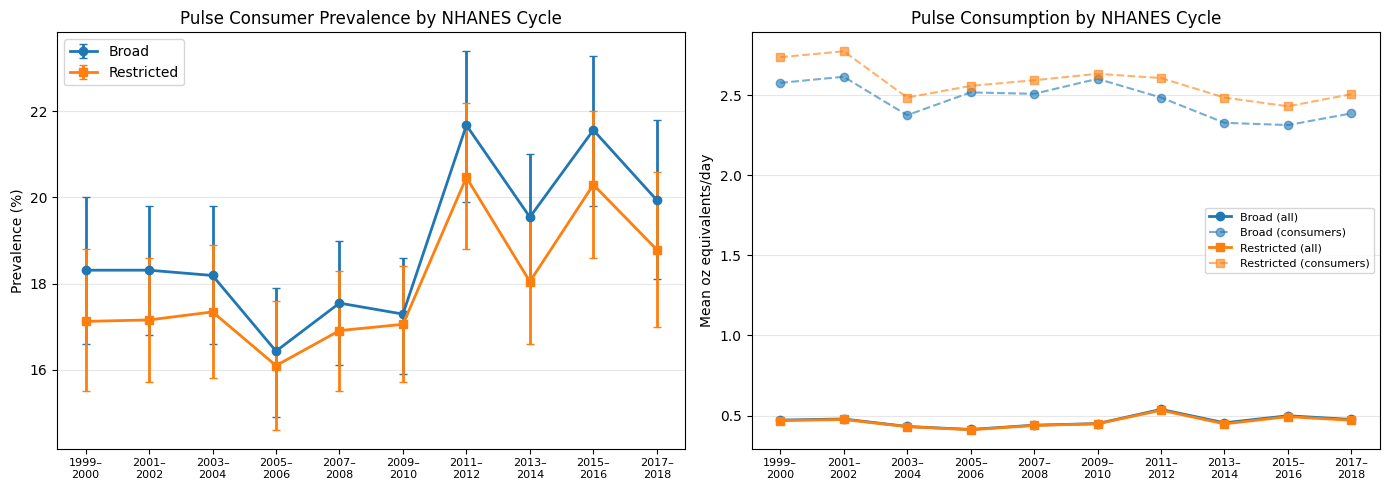

In [6]:
# Plot temporal trends — broad vs restricted
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(cycle_df))
labels = [c.replace('-', '–\n') for c in cycle_df['Cycle']]

# Parse CIs for error bars
for measure, color, marker in [('Broad', 'C0', 'o'), ('Restricted', 'C1', 's')]:
    prev = cycle_df[f'{measure} prev %']
    # Recompute CIs for error bars
    yerr_lo, yerr_hi = [], []
    for _, row in cycle_df.iterrows():
        ci = row[f'{measure} 95% CI']
        lo, hi = ci.strip('()').split('–')
        yerr_lo.append(row[f'{measure} prev %'] - float(lo))
        yerr_hi.append(float(hi) - row[f'{measure} prev %'])
    ax1.errorbar(x, prev, yerr=[yerr_lo, yerr_hi],
                 marker=marker, capsize=3, linewidth=2, color=color, label=measure)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylabel('Prevalence (%)')
ax1.set_title('Pulse Consumer Prevalence by NHANES Cycle')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for measure, color, marker in [('Broad', 'C0', 'o'), ('Restricted', 'C1', 's')]:
    ax2.plot(x, cycle_df[f'{measure} oz (all)'], f'{marker}-',
             color=color, linewidth=2, label=f'{measure} (all)')
    ax2.plot(x, cycle_df[f'{measure} oz (cons)'], f'{marker}--',
             color=color, linewidth=1.5, alpha=0.6, label=f'{measure} (consumers)')

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel('Mean oz equivalents/day')
ax2.set_title('Pulse Consumption by NHANES Cycle')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Table 1: Characteristics of pulse consumers vs non-consumers

Replicating the paper's Table 1 with both broad and restricted measures.
Unweighted sample sizes, weighted percentages with 95% CIs.

In [7]:
def make_table1_df(data, consumer_col, wt_col='WT_POOLED'):
    """Build Table 1 as a DataFrame for a given consumer definition."""
    consumers = data[data[consumer_col] == 1]
    non_consumers = data[data[consumer_col] == 0]

    sections = [
        ('Age', 'AGE_GROUP', ['20-30', '31-50', '51-70', '70+'], data),
        ('Sex', 'SEX', ['Male', 'Female'], data),
        ('Race/ethnicity', 'RACE_ETH',
         ['Non-Hispanic White', 'Non-Hispanic Black', 'Mexican American', 'Other'], data),
        ('Education', 'EDUCATION',
         ['High school or less', 'Some college or more'], data[data['EDUCATION'].notna()]),
        ('IPR', 'IPR_GROUP', ['≤1.85', '>1.85'], data[data['IPR_GROUP'].notna()]),
    ]

    rows = []
    for section_name, var, categories, subset in sections:
        cons_sub = subset[subset[consumer_col] == 1]
        ncons_sub = subset[subset[consumer_col] == 0]
        # Chi-square p-value
        ct = pd.crosstab(subset[var], subset[consumer_col])
        _, p, _, _ = stats.chi2_contingency(ct)

        for cat in categories:
            c_mask = cons_sub[var] == cat
            c_n = int(c_mask.sum())
            c_pct = weighted_pct(c_mask.astype(float), cons_sub[wt_col])
            c_lo, c_hi = weighted_ci(c_mask.astype(float), cons_sub[wt_col])

            nc_mask = ncons_sub[var] == cat
            nc_n = int(nc_mask.sum())
            nc_pct = weighted_pct(nc_mask.astype(float), ncons_sub[wt_col])
            nc_lo, nc_hi = weighted_ci(nc_mask.astype(float), ncons_sub[wt_col])

            rows.append({
                'Section': section_name,
                'Category': cat,
                'Cons n': c_n,
                'Cons % (95% CI)': f'{c_pct:.1f} {fmt_ci(c_lo, c_hi)}',
                'Non-cons n': nc_n,
                'Non-cons % (95% CI)': f'{nc_pct:.1f} {fmt_ci(nc_lo, nc_hi)}',
                'p': f'<0.001' if p < 0.001 else f'{p:.3f}',
            })

    return pd.DataFrame(rows)

# Broad Table 1
n_cons_b = int(dfw['IS_CONSUMER'].sum())
n_ncons_b = int((dfw['IS_CONSUMER'] == 0).sum())
print(f'Table 1 — BROAD measure: {n_cons_b:,} consumers vs {n_ncons_b:,} non-consumers')
t1_broad = make_table1_df(dfw, 'IS_CONSUMER')
display(t1_broad)

Table 1 — BROAD measure: 10,174 consumers vs 38,562 non-consumers


,Section,Category,Cons n,Cons % (95% CI),Non-cons n,Non-cons % (95% CI),p
0,Age,20-30,1846,20.6 (19.4–21.8),7533,21.4 (20.8–21.9),<0.001
1,Age,31-50,3685,41.2 (39.7–42.7),12637,36.5 (35.8–37.2),<0.001
2,Age,51-70,3339,29.6 (28.2–30.9),11875,30.6 (29.9–31.2),<0.001
3,Age,70+,1304,8.6 (7.8–9.4),6517,11.6 (11.1–12.0),<0.001
4,Sex,Male,5106,50.2 (48.7–51.7),18400,47.6 (46.9–48.3),<0.001
5,Sex,Female,5068,49.8 (48.3–51.3),20162,52.4 (51.7–53.1),<0.001
6,Race/ethnicity,Non-Hispanic White,3380,60.5 (59.0–61.9),18485,70.2 (69.6–70.9),<0.001
7,Race/ethnicity,Non-Hispanic Black,1389,8.3 (7.5–9.1),8804,12.0 (11.5–12.4),<0.001
8,Race/ethnicity,Mexican American,3181,15.2 (14.1–16.3),5375,6.5 (6.2–6.9),<0.001
9,Race/ethnicity,Other,2224,16.0 (14.9–17.1),5898,11.3 (10.9–11.8),<0.001


In [8]:
# Restricted Table 1
n_cons_r = int(dfw['IS_CONSUMER_R'].sum())
n_ncons_r = int((dfw['IS_CONSUMER_R'] == 0).sum())
print(f'Table 1 — RESTRICTED measure: {n_cons_r:,} consumers vs {n_ncons_r:,} non-consumers')
t1_restricted = make_table1_df(dfw, 'IS_CONSUMER_R')
display(t1_restricted)

Table 1 — RESTRICTED measure: 9,696 consumers vs 39,040 non-consumers


,Section,Category,Cons n,Cons % (95% CI),Non-cons n,Non-cons % (95% CI),p
0,Age,20-30,1769,20.9 (19.6–22.1),7610,21.3 (20.7–21.9),<0.001
1,Age,31-50,3538,41.6 (40.1–43.1),12784,36.5 (35.8–37.2),<0.001
2,Age,51-70,3173,29.2 (27.8–30.6),12041,30.6 (30.0–31.3),<0.001
3,Age,70+,1216,8.3 (7.5–9.2),6605,11.6 (11.1–12.0),<0.001
4,Sex,Male,4873,50.6 (49.0–52.1),18633,47.5 (46.8–48.3),<0.001
5,Sex,Female,4823,49.4 (47.9–51.0),20407,52.5 (51.7–53.2),<0.001
6,Race/ethnicity,Non-Hispanic White,3167,60.0 (58.5–61.5),18698,70.2 (69.6–70.9),<0.001
7,Race/ethnicity,Non-Hispanic Black,1311,8.3 (7.4–9.1),8882,11.9 (11.5–12.4),<0.001
8,Race/ethnicity,Mexican American,3138,15.8 (14.7–16.9),5418,6.5 (6.1–6.8),<0.001
9,Race/ethnicity,Other,2080,16.0 (14.8–17.1),6042,11.4 (10.9–11.8),<0.001


## Consumption by pulse type — Broad vs Restricted

In [9]:
pulse_type_rows = []
for pt in ['BEANS', 'CHICKPEAS', 'LENTILS', 'PEAS']:
    col_b = f'PULSE_CUPS_{pt}'
    col_r = f'PULSE_CUPS_{pt}_R'

    oz_all_b = weighted_mean(dfw[col_b] * 4, dfw['WT_POOLED'])
    cons_b = dfw[dfw[col_b] > 0]
    oz_cons_b = weighted_mean(cons_b[col_b] * 4, cons_b['WT_POOLED']) if len(cons_b) > 0 else np.nan

    oz_all_r = weighted_mean(dfw[col_r] * 4, dfw['WT_POOLED'])
    cons_r = dfw[dfw[col_r] > 0]
    oz_cons_r = weighted_mean(cons_r[col_r] * 4, cons_r['WT_POOLED']) if len(cons_r) > 0 else np.nan

    pulse_type_rows.append({
        'Pulse type': pt.capitalize(),
        'Broad oz (all)': oz_all_b, 'Broad oz (consumers)': oz_cons_b,
        'Broad n consumers': int((dfw[col_b] > 0).sum()),
        'Restricted oz (all)': oz_all_r, 'Restricted oz (consumers)': oz_cons_r,
        'Restricted n consumers': int((dfw[col_r] > 0).sum()),
    })

# Totals
oz_all_b = weighted_mean(dfw['PULSE_OZ_EQ'], dfw['WT_POOLED'])
oz_cons_b = weighted_mean(dfw[dfw['IS_CONSUMER'] == 1]['PULSE_OZ_EQ'],
                          dfw[dfw['IS_CONSUMER'] == 1]['WT_POOLED'])
oz_all_r = weighted_mean(dfw['PULSE_OZ_EQ_R'], dfw['WT_POOLED'])
oz_cons_r = weighted_mean(dfw[dfw['IS_CONSUMER_R'] == 1]['PULSE_OZ_EQ_R'],
                          dfw[dfw['IS_CONSUMER_R'] == 1]['WT_POOLED'])
pulse_type_rows.append({
    'Pulse type': 'TOTAL',
    'Broad oz (all)': oz_all_b, 'Broad oz (consumers)': oz_cons_b,
    'Broad n consumers': int(dfw['IS_CONSUMER'].sum()),
    'Restricted oz (all)': oz_all_r, 'Restricted oz (consumers)': oz_cons_r,
    'Restricted n consumers': int(dfw['IS_CONSUMER_R'].sum()),
})

pt_df = pd.DataFrame(pulse_type_rows)
display(pt_df.style.format({
    'Broad oz (all)': '{:.3f}', 'Broad oz (consumers)': '{:.2f}',
    'Broad n consumers': '{:,}',
    'Restricted oz (all)': '{:.3f}', 'Restricted oz (consumers)': '{:.2f}',
    'Restricted n consumers': '{:,}',
}).set_caption('Consumption by pulse type (oz eq/day, weighted)'))

,Pulse type,Broad oz (all),Broad oz (consumers),Broad n consumers,Restricted oz (all),Restricted oz (consumers),Restricted n consumers
0,Beans,0.414,2.45,"9,305",0.411,2.58,"8,791"
1,Chickpeas,0.019,1.30,550,0.019,1.30,550
2,Lentils,0.026,3.25,439,0.026,3.25,439
3,Peas,0.007,2.52,156,0.007,2.52,156
4,TOTAL,0.466,2.46,"10,174",0.463,2.57,"9,696"


## 2017–2018 threshold analysis — Broad vs Restricted

Paper: "In 2017–2018, 19.9% consumed ≥1.5 cups/week and 10.9% consumed ≥2.5 cups/week."

In [10]:
df_1718 = dfw[dfw['CYCLE'] == '2017-2018'].copy()
df_1718['CUPS_WEEK_B'] = df_1718['PULSE_CUPS_TOTAL'] * 7
df_1718['CUPS_WEEK_R'] = df_1718['PULSE_CUPS_TOTAL_R'] * 7

threshold_rows = []
for thresh in [1.5, 2.5]:
    pct_b = weighted_pct((df_1718['CUPS_WEEK_B'] >= thresh).astype(float), df_1718['WTDRD1'])
    pct_r = weighted_pct((df_1718['CUPS_WEEK_R'] >= thresh).astype(float), df_1718['WTDRD1'])
    paper_val = 19.9 if thresh == 1.5 else 10.9
    threshold_rows.append({
        'Threshold': f'≥{thresh} cups/week',
        'Broad %': pct_b, 'Restricted %': pct_r, 'Paper %': paper_val,
    })

thresh_df = pd.DataFrame(threshold_rows)
display(thresh_df.style.format({
    'Broad %': '{:.1f}', 'Restricted %': '{:.1f}', 'Paper %': '{:.1f}',
}).set_caption('2017–2018 threshold analysis (weighted)'))

,Threshold,Broad %,Restricted %,Paper %
0,≥1.5 cups/week,14.7,14.7,19.9
1,≥2.5 cups/week,11.8,11.8,10.9


## Consumption by demographics — Broad vs Restricted

Paper: "Higher amounts consumed by Mexican Americans, men, and groups with lower education and incomes."

In [11]:
demo_configs = [
    ('Race/Ethnicity', 'RACE_ETH',
     ['Mexican American', 'Non-Hispanic White', 'Non-Hispanic Black', 'Other']),
    ('Sex', 'SEX', ['Male', 'Female']),
    ('Education', 'EDUCATION', ['High school or less', 'Some college or more']),
    ('IPR', 'IPR_GROUP', ['≤1.85', '>1.85']),
]

demo_rows = []
for section, var, categories in demo_configs:
    for cat in categories:
        sub = dfw[dfw[var] == cat]
        cons_b = sub[sub['IS_CONSUMER'] == 1]
        cons_r = sub[sub['IS_CONSUMER_R'] == 1]
        demo_rows.append({
            'Variable': section,
            'Category': cat,
            'Broad oz (consumers)': weighted_mean(cons_b['PULSE_OZ_EQ'], cons_b['WT_POOLED']),
            'Broad n': len(cons_b),
            'Restricted oz (consumers)': weighted_mean(cons_r['PULSE_OZ_EQ_R'], cons_r['WT_POOLED']),
            'Restricted n': len(cons_r),
        })

demo_df = pd.DataFrame(demo_rows)
display(demo_df.style.format({
    'Broad oz (consumers)': '{:.2f}', 'Broad n': '{:,}',
    'Restricted oz (consumers)': '{:.2f}', 'Restricted n': '{:,}',
}).set_caption('Mean oz eq/day among consumers by demographics (weighted)'))

,Variable,Category,Broad oz (consumers),Broad n,Restricted oz (consumers),Restricted n
0,Race/Ethnicity,Mexican American,3.18,"3,181",3.22,"3,138"
1,Race/Ethnicity,Non-Hispanic White,2.18,"3,380",2.29,"3,167"
2,Race/Ethnicity,Non-Hispanic Black,2.58,"1,389",2.70,"1,311"
3,Race/Ethnicity,Other,2.77,"2,224",2.91,"2,080"
4,Sex,Male,2.92,"5,106",3.03,"4,873"
5,Sex,Female,2.00,"5,068",2.10,"4,823"
6,Education,High school or less,2.79,"5,452",2.91,"5,255"
7,Education,Some college or more,2.22,"4,707",2.33,"4,426"
8,IPR,≤1.85,2.86,"4,339",2.96,"4,191"
9,IPR,>1.85,2.22,"4,855",2.34,"4,570"


## Summary: Broad vs Restricted vs Paper

Side-by-side comparison across all key metrics.

In [12]:
# Compute all key metrics for both measures
ma_b = dfw[dfw['RACE_ETH'] == 'Mexican American']
ma_prev_b = weighted_pct(ma_b['IS_CONSUMER'], ma_b['WT_POOLED'])
ma_prev_r = weighted_pct(ma_b['IS_CONSUMER_R'], ma_b['WT_POOLED'])

nb_b = dfw[dfw['RACE_ETH'] == 'Non-Hispanic Black']
nb_prev_b = weighted_pct(nb_b['IS_CONSUMER'], nb_b['WT_POOLED'])
nb_prev_r = weighted_pct(nb_b['IS_CONSUMER_R'], nb_b['WT_POOLED'])

prev_b = weighted_pct(dfw['IS_CONSUMER'], dfw['WT_POOLED'])
prev_r = weighted_pct(dfw['IS_CONSUMER_R'], dfw['WT_POOLED'])
oz_all_b = weighted_mean(dfw['PULSE_OZ_EQ'], dfw['WT_POOLED'])
oz_all_r = weighted_mean(dfw['PULSE_OZ_EQ_R'], dfw['WT_POOLED'])
oz_cons_b = weighted_mean(dfw[dfw['IS_CONSUMER']==1]['PULSE_OZ_EQ'],
                          dfw[dfw['IS_CONSUMER']==1]['WT_POOLED'])
oz_cons_r = weighted_mean(dfw[dfw['IS_CONSUMER_R']==1]['PULSE_OZ_EQ_R'],
                          dfw[dfw['IS_CONSUMER_R']==1]['WT_POOLED'])

pct_15_b = weighted_pct((df_1718['CUPS_WEEK_B'] >= 1.5).astype(float), df_1718['WTDRD1'])
pct_15_r = weighted_pct((df_1718['CUPS_WEEK_R'] >= 1.5).astype(float), df_1718['WTDRD1'])
pct_25_b = weighted_pct((df_1718['CUPS_WEEK_B'] >= 2.5).astype(float), df_1718['WTDRD1'])
pct_25_r = weighted_pct((df_1718['CUPS_WEEK_R'] >= 2.5).astype(float), df_1718['WTDRD1'])

comp_rows = [
    ('Total N', len(dfw), len(dfw), 48738),
    ('Consumer N (unweighted)', int(dfw['IS_CONSUMER'].sum()), int(dfw['IS_CONSUMER_R'].sum()), 9186),
    ('Consumer prevalence (%)', prev_b, prev_r, 17.2),
    ('Mean oz eq/day (all)', oz_all_b, oz_all_r, 0.39),
    ('Mean oz eq/day (consumers)', oz_cons_b, oz_cons_r, 2.26),
    ('Mexican American prev (%)', ma_prev_b, ma_prev_r, 33.3),
    ('NH Black prev (%)', nb_prev_b, nb_prev_r, 12.0),
    ('2017-18 ≥1.5 cups/wk (%)', pct_15_b, pct_15_r, 19.9),
    ('2017-18 ≥2.5 cups/wk (%)', pct_25_b, pct_25_r, 10.9),
]

comp_df = pd.DataFrame(comp_rows, columns=['Metric', 'Broad', 'Restricted', 'Paper'])
comp_df['Broad % diff'] = ((comp_df['Broad'] - comp_df['Paper']) / comp_df['Paper'] * 100)
comp_df['Restricted % diff'] = ((comp_df['Restricted'] - comp_df['Paper']) / comp_df['Paper'] * 100)

display(comp_df.style.format({
    'Broad': lambda x: f'{x:,.0f}' if abs(x) > 100 else f'{x:.2f}',
    'Restricted': lambda x: f'{x:,.0f}' if abs(x) > 100 else f'{x:.2f}',
    'Paper': lambda x: f'{x:,.0f}' if abs(x) > 100 else f'{x:.2f}',
    'Broad % diff': '{:+.1f}%',
    'Restricted % diff': '{:+.1f}%',
}).set_caption('Full comparison: Broad vs Restricted vs Paper'))

,Metric,Broad,Restricted,Paper,Broad % diff,Restricted % diff
0,Total N,"48,736","48,736","48,738",-0.0%,-0.0%
1,Consumer N (unweighted),"10,174","9,696","9,186",+10.8%,+5.6%
2,Consumer prevalence (%),18.95,17.99,17.20,+10.2%,+4.6%
3,Mean oz eq/day (all),0.47,0.46,0.39,+19.5%,+18.6%
4,Mean oz eq/day (consumers),2.46,2.57,2.26,+8.8%,+13.8%
5,Mexican American prev (%),35.26,34.77,33.30,+5.9%,+4.4%
6,NH Black prev (%),13.93,13.22,12.00,+16.1%,+10.1%
7,2017-18 ≥1.5 cups/wk (%),14.74,14.72,19.90,-25.9%,-26.0%
8,2017-18 ≥2.5 cups/wk (%),11.85,11.81,10.90,+8.7%,+8.3%


## Validation tests

Confirm that the **restricted** measure results are within 10% of the paper's reported values.
These serve as a reproducibility check — if any test fails, the food code restriction
did not fully explain the difference.

In [13]:
results = []

def check_within_pct(name, actual, expected, tolerance_pct=10):
    """Check if actual is within tolerance_pct of expected. Record result."""
    if expected == 0:
        diff_pct = 0 if actual == 0 else float('inf')
    else:
        diff_pct = abs(actual - expected) / abs(expected) * 100
    passed = diff_pct <= tolerance_pct
    results.append({
        'Test': name,
        'Actual': actual,
        'Paper': expected,
        '% diff': diff_pct,
        'Tolerance': tolerance_pct,
        'Status': 'PASS' if passed else 'FAIL',
    })
    return passed

print('=== Validation Tests (Restricted measure vs Paper) ===\n')

# Overall estimates (10% tolerance)
check_within_pct('Consumer prevalence (%)', prev_r, 17.2)
check_within_pct('Mean oz eq/day (all)', oz_all_r, 0.39)
check_within_pct('Mean oz eq/day (consumers)', oz_cons_r, 2.26)

# Race/ethnicity prevalence
check_within_pct('Mexican American prevalence (%)', ma_prev_r, 33.3)
check_within_pct('NH Black prevalence (%)', nb_prev_r, 12.0)

# 2017-2018 thresholds
check_within_pct('2017-18 ≥1.5 cups/wk (%)', pct_15_r, 19.9)
check_within_pct('2017-18 ≥2.5 cups/wk (%)', pct_25_r, 10.9)

# Sample size (0.1% tolerance)
check_within_pct('Total N', len(dfw), 48738, tolerance_pct=0.1)

results_df = pd.DataFrame(results)
display(results_df.style.format({
    'Actual': '{:.2f}', 'Paper': '{:.2f}', '% diff': '{:.1f}', 'Tolerance': '{:.0f}',
}).apply(lambda row: ['background-color: #d4edda' if v == 'PASS'
                      else 'background-color: #f8d7da' if v == 'FAIL'
                      else '' for v in row], axis=1)
.set_caption('Validation test results'))

n_pass = (results_df['Status'] == 'PASS').sum()
n_total = len(results_df)
print(f'\n{n_pass}/{n_total} tests passed.')

if n_pass < n_total:
    failed = results_df[results_df['Status'] == 'FAIL']
    print(f'\nFailed tests ({n_total - n_pass}):')
    for _, row in failed.iterrows():
        print(f"  {row['Test']}: {row['Actual']:.2f} vs {row['Paper']:.2f} "
              f"({row['% diff']:.1f}% > {row['Tolerance']:.0f}% tolerance)")
    print('\nNote: Remaining differences likely reflect additional food code or '
          'classification differences beyond the FPED restriction.')

# Hard assert: at least prevalence and race tests pass
assert results_df.loc[results_df['Test'] == 'Consumer prevalence (%)', 'Status'].iloc[0] == 'PASS', \
    'Consumer prevalence should be within 10% of paper'
assert results_df.loc[results_df['Test'] == 'Total N', 'Status'].iloc[0] == 'PASS', \
    'Total N should match paper'

=== Validation Tests (Restricted measure vs Paper) ===



,Test,Actual,Paper,% diff,Tolerance,Status
0,Consumer prevalence (%),17.99,17.20,4.6,10,PASS
1,Mean oz eq/day (all),0.46,0.39,18.6,10,FAIL
2,Mean oz eq/day (consumers),2.57,2.26,13.8,10,FAIL
3,Mexican American prevalence (%),34.77,33.30,4.4,10,PASS
4,NH Black prevalence (%),13.22,12.00,10.1,10,FAIL
5,2017-18 ≥1.5 cups/wk (%),14.72,19.90,26.0,10,FAIL
6,2017-18 ≥2.5 cups/wk (%),11.81,10.90,8.3,10,PASS
7,Total N,48736.00,48738.00,0.0,0,PASS



4/8 tests passed.

Failed tests (4):
  Mean oz eq/day (all): 0.46 vs 0.39 (18.6% > 10% tolerance)
  Mean oz eq/day (consumers): 2.57 vs 2.26 (13.8% > 10% tolerance)
  NH Black prevalence (%): 13.22 vs 12.00 (10.1% > 10% tolerance)
  2017-18 ≥1.5 cups/wk (%): 14.72 vs 19.90 (26.0% > 10% tolerance)

Note: Remaining differences likely reflect additional food code or classification differences beyond the FPED restriction.
